In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.synthetic import HawkesSimulator
from src import run_validation_loop, HawkesModel, ScaledPoisson


In [13]:
sim = HawkesSimulator(t_max=24*30)
synthetic_seq, df_true = sim.generate_dataset(n_users=100)

print(f"Generated {len(synthetic_seq)} users with events.")

Generating synthetic data for 100 users...


100%|██████████| 100/100 [00:00<00:00, 715.52it/s]

Generated 100 users with events.


In [14]:
factory_hawkes = lambda p: HawkesModel(p, penalty_weight=1.0, kernel='exp')
df_pred = run_validation_loop(synthetic_seq, factory_hawkes, label="SyntheticRun", min_events=20)

Running 'SyntheticRun': N=100


100%|██████████| 100/100 [00:05<00:00, 20.00it/s]



Metric Recovery Results:
Alpha Correlation: 0.946 (Should be > 0.5)
Beta Correlation:  0.658 (Should be > 0.5)
LL Win Rate:       90.0% (Should be ~100%)


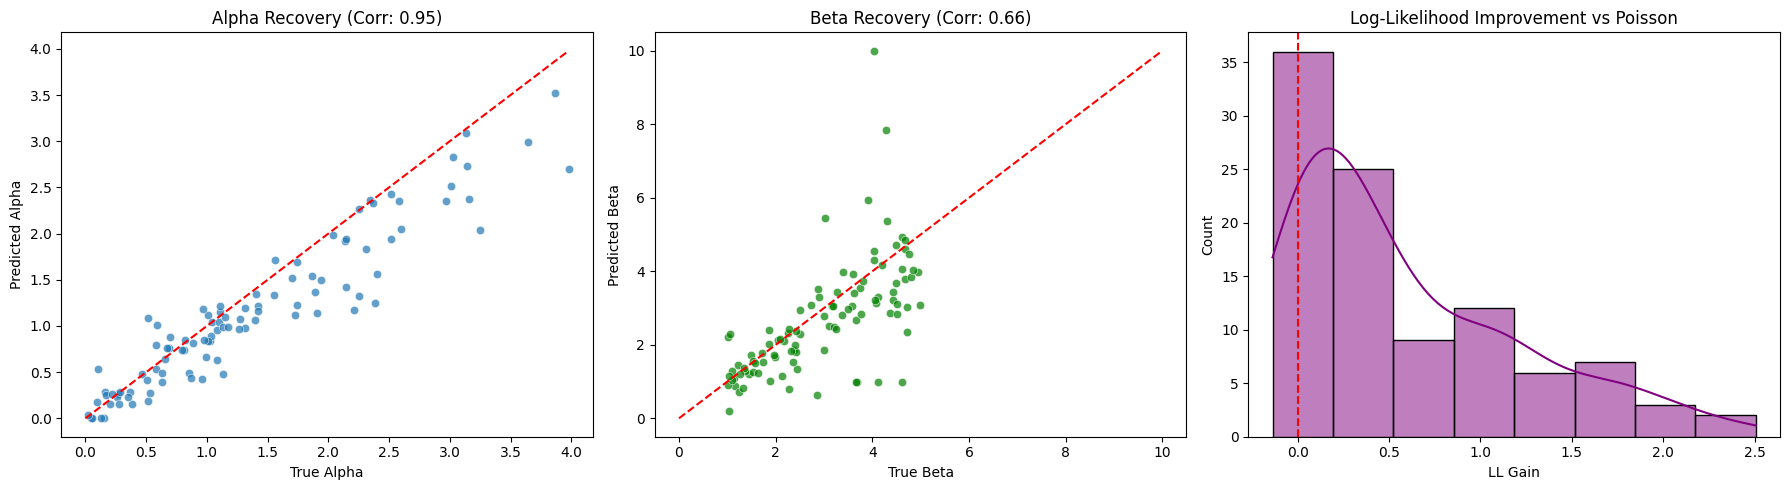

In [15]:
# --- 3. MERGE & VISUALIZE ---
df_final = pd.merge(df_true, df_pred, on='user_id')

corr_a = df_final['true_alpha'].corr(df_final['alpha'])
corr_b = df_final['true_beta'].corr(df_final['beta'])
win_rate = df_final['win_ll'].mean()

print(f"\nMetric Recovery Results:")
print(f"Alpha Correlation: {corr_a:.3f} (Should be > 0.5)")
print(f"Beta Correlation:  {corr_b:.3f} (Should be > 0.5)")
print(f"LL Win Rate:       {win_rate:.1%} (Should be ~100%)")

# --- PLOTTING ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_final, x='true_alpha', y='alpha', ax=ax[0], alpha=0.7)
max_val = max(df_final['true_alpha'].max(), df_final['alpha'].max())
ax[0].plot([0, max_val], [0, max_val], 'r--', label='Ideal')
ax[0].set_title(f'Alpha Recovery (Corr: {corr_a:.2f})')
ax[0].set_xlabel('True Alpha')
ax[0].set_ylabel('Predicted Alpha')

# 2. Beta Recovery
sns.scatterplot(data=df_final, x='true_beta', y='beta', ax=ax[1], color='green', alpha=0.7)
max_val_b = max(df_final['true_beta'].max(), df_final['beta'].max())
ax[1].plot([0, max_val_b], [0, max_val_b], 'r--', label='Ideal')
ax[1].set_title(f'Beta Recovery (Corr: {corr_b:.2f})')
ax[1].set_xlabel('True Beta')
ax[1].set_ylabel('Predicted Beta')

# 3. LL Improvement
sns.histplot(df_final['imp_ll'], ax=ax[2], color='purple', kde=True)
ax[2].axvline(0, c='red', ls='--')
ax[2].set_title('Log-Likelihood Improvement vs Poisson')
ax[2].set_xlabel('LL Gain')

plt.tight_layout()
plt.show()

**With scaled poisson**

In [21]:
print("Generating Synthetic Data...")
sim = HawkesSimulator(t_max=24*30) 
synthetic_seq, df_true = sim.generate_dataset(n_users=100)

Generating Synthetic Data...
Generating synthetic data for 100 users...


100%|██████████| 100/100 [00:00<00:00, 633.73it/s]


In [24]:
print(">>> Running Scaled Poisson (Simple)...")
factory_scaled = lambda p: ScaledPoisson(p)
df_scaled = run_validation_loop(synthetic_seq, factory_scaled, label="Scaled", min_events=30)

print(">>> Running Hawkes Exp (Complex)...")
factory_hawkes = lambda p: HawkesModel(p, penalty_weight=1.0, kernel='exp') 
df_hawkes = run_validation_loop(synthetic_seq, factory_hawkes, label="Hawkes", min_events=30)


>>> Running Scaled Poisson (Simple)...
Running 'Scaled': N=100


100%|██████████| 100/100 [00:00<00:00, 877.11it/s]


>>> Running Hawkes Exp (Complex)...
Running 'Hawkes': N=100


100%|██████████| 100/100 [00:05<00:00, 19.88it/s]



Avg LL Gain: 0.6303
Win Rate: 91.0%


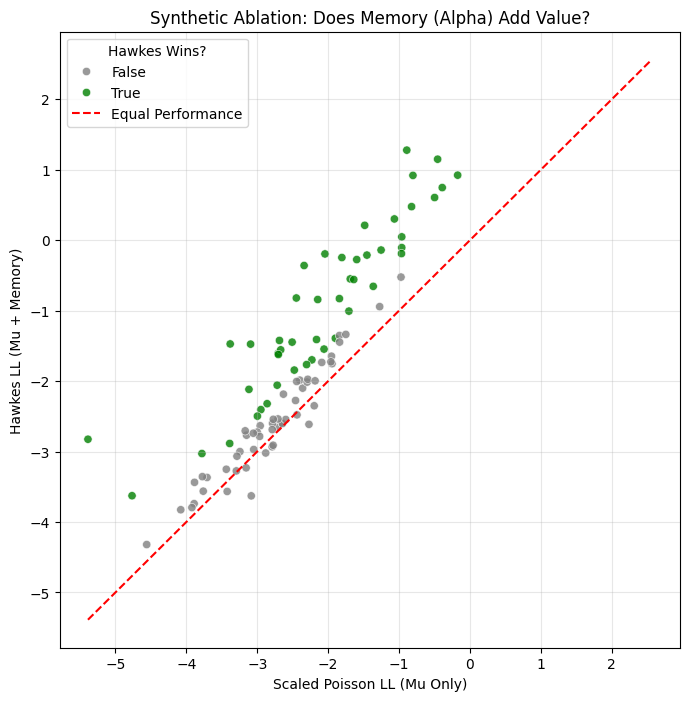

In [25]:
if not df_scaled.empty and not df_hawkes.empty:
    df_comp = pd.merge(df_scaled[['user_id', 'll_model']], 
                       df_hawkes[['user_id', 'll_model']], 
                       on='user_id', suffixes=('_scaled', '_hawkes'))

    df_comp['gain'] = df_comp['ll_model_hawkes'] - df_comp['ll_model_scaled']
    
    print(f"\nAvg LL Gain: {df_comp['gain'].mean():.4f}")
    print(f"Win Rate: {(df_comp['gain'] > 0).mean():.1%}")

    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=df_comp, x='ll_model_scaled', y='ll_model_hawkes', 
                    hue=df_comp['gain'] > 0.5, palette={True: 'green', False: 'gray'}, alpha=0.8)
    
    min_v = min(df_comp.min(numeric_only=True))
    max_v = max(df_comp.max(numeric_only=True))
    plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='Equal Performance')
    
    plt.title("Synthetic Ablation: Does Memory (Alpha) Add Value?")
    plt.xlabel("Scaled Poisson LL (Mu Only)")
    plt.ylabel("Hawkes LL (Mu + Memory)")
    plt.legend(title="Hawkes Wins?")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: Results empty.")